In [1]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

In [2]:
df = pd.read_csv("../data/processed_telco_data.csv")

In [3]:
X = df.drop('Churn Value', axis=1)

y = df['Churn Value']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
print(X_train.shape)
print(X_test.shape)

(5634, 30)
(1409, 30)


In [6]:
lr = LogisticRegression(
    random_state=42
)

lr.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [7]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [8]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [9]:
xgb = XGBClassifier(
    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [10]:
lr_pred = lr.predict(X_test)

In [11]:
dt_pred = dt.predict(X_test)

In [12]:
rf_pred = rf.predict(X_test)

In [13]:
xgb_pred = xgb.predict(X_test)

In [14]:
lr_prob = lr.predict_proba(X_test)[:,1]

dt_prob = dt.predict_proba(X_test)[:,1]

rf_prob = rf.predict_proba(X_test)[:,1]

xgb_prob = xgb.predict_proba(X_test)[:,1]

In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [16]:
def evaluate_model(y_true,
                   y_pred,
                   y_prob):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred
    )

    recall = recall_score(
        y_true,
        y_pred
    )

    f1 = f1_score(
        y_true,
        y_pred
    )

    roc_auc = roc_auc_score(
        y_true,
        y_prob
    )

    return [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]

In [17]:
results = pd.DataFrame({

'Logistic Regression':
evaluate_model(
    y_test,
    lr_pred,
    lr_prob
),

'Decision Tree':
evaluate_model(
    y_test,
    dt_pred,
    dt_prob
),

'Random Forest':
evaluate_model(
    y_test,
    rf_pred,
    rf_prob
),

'XGBoost':
evaluate_model(
    y_test,
    xgb_pred,
    xgb_prob
)

},

index=[
'Accuracy',
'Precision',
'Recall',
'F1 Score',
'ROC AUC'
]
)

print(results)

           Logistic Regression  Decision Tree  Random Forest   XGBoost
Accuracy              0.799858       0.730305       0.789212  0.790632
Precision             0.637725       0.492063       0.623003  0.617211
Recall                0.569519       0.497326       0.521390  0.556150
F1 Score              0.601695       0.494681       0.567686  0.585091
ROC AUC               0.848568       0.655424       0.834608  0.833376


In [18]:
best_model = lr

In [19]:
importance = pd.DataFrame({

    'Feature': X.columns,

    'Coefficient': best_model.coef_[0]

})

importance['Absolute Value'] = abs(
    importance['Coefficient']
)

importance = importance.sort_values(
    by='Absolute Value',
    ascending=False
)

print(importance.head(10))

                         Feature  Coefficient  Absolute Value
0                  Tenure Months    -1.258281        1.258281
1                Monthly Charges    -0.797388        0.797388
10  Internet Service_Fiber optic     0.699324        0.699324
6                 Dependents_Yes    -0.691160        0.691160
25             Contract_Two year    -0.572569        0.572569
2                  Total Charges     0.507829        0.507829
24             Contract_One year    -0.301423        0.301423
21              Streaming TV_Yes     0.241622        0.241622
23          Streaming Movies_Yes     0.231179        0.231179
9             Multiple Lines_Yes     0.214570        0.214570


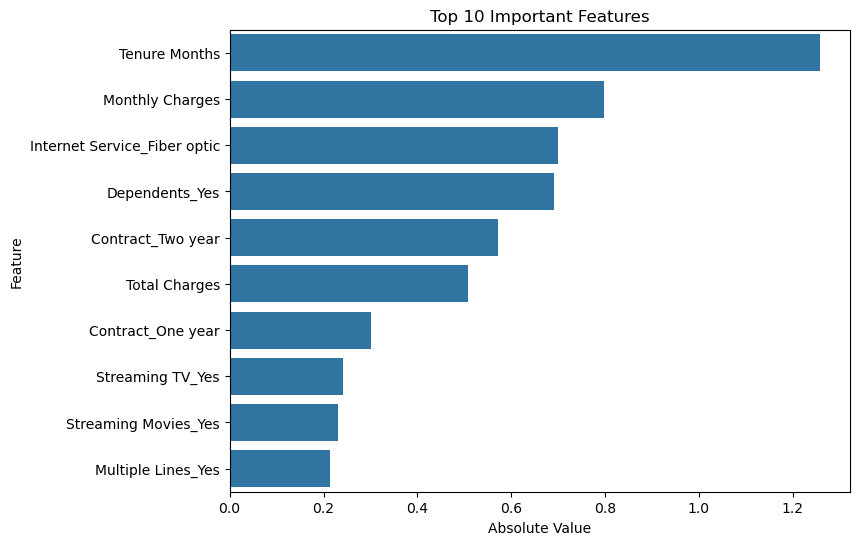

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

top10 = importance.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top10,
    x='Absolute Value',
    y='Feature'
)

plt.title("Top 10 Important Features")

plt.show()

In [21]:
import pickle

pickle.dump(
    best_model,
    open(
        "../models/churn_model.pkl",
        "wb"
    )
)

In [22]:
importance.to_csv(
    "../data/feature_importance.csv",
    index=False
)

In [23]:
X.columns

Index(['Tenure Months', 'Monthly Charges', 'Total Charges', 'Gender_Male',
       'Senior Citizen_Yes', 'Partner_Yes', 'Dependents_Yes',
       'Phone Service_Yes', 'Multiple Lines_No phone service',
       'Multiple Lines_Yes', 'Internet Service_Fiber optic',
       'Internet Service_No', 'Online Security_No internet service',
       'Online Security_Yes', 'Online Backup_No internet service',
       'Online Backup_Yes', 'Device Protection_No internet service',
       'Device Protection_Yes', 'Tech Support_No internet service',
       'Tech Support_Yes', 'Streaming TV_No internet service',
       'Streaming TV_Yes', 'Streaming Movies_No internet service',
       'Streaming Movies_Yes', 'Contract_One year', 'Contract_Two year',
       'Paperless Billing_Yes', 'Payment Method_Credit card (automatic)',
       'Payment Method_Electronic check', 'Payment Method_Mailed check'],
      dtype='object')